# Flood Risk Prediction Model - FIXED VERSION
## Organized & Robust (Error Handling Included)

**IMPORTANT:** This version includes error handling and diagnostics

- ✅ Robust data loading with error messages
- ✅ Column verification and debugging
- ✅ Better error reporting
- ✅ Data validation before processing

**Date:** February 24, 2026  
**Status:** ✅ Production Ready with Diagnostics

## ⚠️ STEP 0: Configure Your Paths & Run Diagnostic

In [3]:
from pathlib import Path
import pandas as pd

# ⚠️ CHANGE THESE PATHS TO YOUR DATA
DATA_DIR = Path('/Users/mac/Documents/Innond/flood_api/donnees').resolve()
MODELS_DIR = Path('/Users/mac/Documents/Innond/flood_api/models').resolve()

print(f'DATA_DIR: {DATA_DIR}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'\n✓ Data directory exists: {DATA_DIR.exists()}')
print(f'✓ Models directory exists: {MODELS_DIR.exists()}')

DATA_DIR: /Users/mac/Documents/Innond/flood_api/donnees
MODELS_DIR: /Users/mac/Documents/Innond/flood_api/models

✓ Data directory exists: True
✓ Models directory exists: True


In [4]:
# Check for CSV files
csv_files = list(DATA_DIR.glob('*.csv'))
print(f'\n📁 CSV files found: {len(csv_files)}')
for f in csv_files:
    print(f'   - {f.name}')

if not csv_files:
    print('\n❌ ERROR: No CSV files found!')
    print(f'   Check that DATA_DIR points to folder with CSV files')
else:
    print(f'\n✅ Ready to load data!')


📁 CSV files found: 6
   - touba_2005_2025.csv
   - kaolack_leona_2005_2025.csv
   - keur_massar_2005_2025.csv
   - tambacounda_2005_2025.csv
   - matam_2005_2025.csv
   - kolda_2005_2025.csv

✅ Ready to load data!


In [5]:
# Examine first CSV file structure
if csv_files:
    first_file = csv_files[0]
    print(f'\nExamining: {first_file.name}')
    print('\n--- First 3 rows (with metadata) ---')
    df_meta = pd.read_csv(first_file, nrows=3)
    print(df_meta)
    
    print('\n--- Row 4-6 (actual data, after skiprows=3) ---')
    df_data = pd.read_csv(first_file, skiprows=3, nrows=3)
    print(df_data)
    print(f'\nColumns in data: {list(df_data.columns)}')
    print(f'Has "time" column: {"time" in df_data.columns}')
    print(f'Has "location" column: {"location" in df_data.columns}')


Examining: touba_2005_2025.csv

--- First 3 rows (with metadata) ---


ParserError: Error tokenizing data. C error: Expected 6 fields in line 4, saw 43


## Section 1: Imports & Configuration

In [6]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Dict, Iterable, List, Tuple
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

print('✓ All imports successful')

✓ All imports successful


## Section 2: Global Parameters

In [7]:
# Model decision threshold
SEUIL_OPTIMAL = 0.35
RAINY_MONTHS = {6, 7, 8, 9, 10}

# Visualization settings
plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'axes.titleweight': 'semibold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.titlesize': 16,
    'legend.fontsize': 11,
})

print('✓ Configuration set')

✓ Configuration set


## Section 3: Data Loading Functions (WITH ERROR HANDLING)

In [8]:
SUBSTITUTIONS = {
    ' ': '_', '/': '_per_', '%': 'pct', '°': 'deg',
    '²': '2', '³': '3', '(': '', ')': '', '-': '_',
}

AGGREGATION_MAP = {
    'precipitation_mm': ('sum', 'max'),
    'rain_mm': ('sum', 'max'),
    'relative_humidity_2m_pct': ('mean', 'min', 'max'),
    'temperature_2m_degc': ('mean', 'min', 'max'),
    'dew_point_2m_degc': ('mean',),
    'vapour_pressure_deficit_kpa': ('mean', 'max'),
    'wind_gusts_10m_km_per_h': ('mean', 'max'),
    'soil_moisture_0_to_7cm_m3_per_m3': ('mean', 'max'),
    'cloud_cover_pct': ('mean',),
    'et0_fao_evapotranspiration_mm': ('sum',),
    'shortwave_radiation_w_per_m2': ('sum', 'mean'),
}

GEO_COLUMNS = ('latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'region')

def normalise_column(label: str) -> str:
    """Normalize column names."""
    label = label.strip().lower()
    for src, dst in SUBSTITUTIONS.items():
        label = label.replace(src, dst)
    while '__' in label:
        label = label.replace('__', '_')
    return label.strip('_')

def extract_metadata(path: Path) -> Dict[str, str]:
    """Extract metadata from CSV header."""
    try:
        head = pd.read_csv(path, nrows=1, encoding='utf-8')
        if head.empty:
            return {}
        return {normalise_column(k): v for k, v in head.iloc[0].to_dict().items()}
    except Exception as e:
        print(f'⚠️  Warning reading metadata from {path.name}: {e}')
        return {}

def coerce_float(value: object) -> float:
    """Safely convert to float."""
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def location_from_path(path: Path) -> str:
    """Extract location from filename."""
    parts = path.stem.split('_')
    if len(parts) >= 3 and all(p.isdigit() for p in parts[-2:]):
        return '_'.join(parts[:-2])
    return path.stem

print('✓ Utility functions defined')

✓ Utility functions defined


## Section 4: Load Data (ROBUST VERSION)

In [9]:
def load_hourly_data(data_dir: Path) -> pd.DataFrame:
    """Load hourly data with comprehensive error handling."""
    frames = []
    
    csv_files = sorted(data_dir.glob('*.csv'))
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found in {data_dir}')
    
    print(f'Loading {len(csv_files)} CSV file(s)...')
    
    for i, csv_path in enumerate(csv_files, 1):
        print(f'  [{i}/{len(csv_files)}] {csv_path.name}...', end=' ')
        try:
            metadata = extract_metadata(csv_path)
            frame = pd.read_csv(csv_path, skiprows=3, encoding='utf-8')
            
            # Normalize column names
            frame.columns = [normalise_column(c) for c in frame.columns]
            
            # Check for time column
            if 'time' not in frame.columns:
                raise ValueError(f'Missing "time" column. Available: {list(frame.columns)}')
            
            # Process time column
            frame['time'] = pd.to_datetime(frame['time'], errors='coerce')
            frame = frame.dropna(subset=['time'])
            
            # Convert numeric columns
            numeric_cols = [c for c in frame.columns if c != 'time']
            frame[numeric_cols] = frame[numeric_cols].apply(pd.to_numeric, errors='coerce')
            
            # Add location and metadata
            frame['location'] = location_from_path(csv_path)
            frame['region'] = metadata.get('region') or np.nan
            
            for geo_col in ('latitude', 'longitude', 'elevation', 'utc_offset_seconds'):
                frame[geo_col] = coerce_float(metadata.get(geo_col))
            
            frames.append(frame)
            print('✓')
        
        except Exception as e:
            print(f'❌ ERROR: {e}')
            raise
    
    data = pd.concat(frames, ignore_index=True)
    print(f'\n✓ Loaded {len(data)} rows from {len(frames)} file(s)')
    print(f'  Columns: {list(data.columns)}')
    print(f'  Locations: {data["location"].unique().tolist()}')
    return data.sort_values(['location', 'time'])

# Load data
try:
    hourly = load_hourly_data(DATA_DIR)
    print(f'\n✅ Data loaded successfully!')
except Exception as e:
    print(f'\n❌ FAILED TO LOAD DATA')
    print(f'Error: {e}')
    print(f'\nPlease check:')
    print(f'  1. DATA_DIR is correct: {DATA_DIR}')
    print(f'  2. CSV files exist in that directory')
    print(f'  3. CSV files have "time" column')
    print(f'  4. CSV data starts after 3 header rows')
    raise

Loading 6 CSV file(s)...
  [1/6] kaolack_leona_2005_2025.csv... ✓
  [2/6] keur_massar_2005_2025.csv... ✓
  [3/6] kolda_2005_2025.csv... ✓
  [4/6] matam_2005_2025.csv... ✓
  [5/6] tambacounda_2005_2025.csv... ✓
  [6/6] touba_2005_2025.csv... ✓

✓ Loaded 1068624 rows from 6 file(s)
  Columns: ['time', 'temperature_2m_degc', 'relative_humidity_2m_pct', 'dew_point_2m_degc', 'apparent_temperature_degc', 'precipitation_mm', 'rain_mm', 'snowfall_cm', 'snow_depth_m', 'weather_code_wmo_code', 'pressure_msl_hpa', 'surface_pressure_hpa', 'cloud_cover_pct', 'cloud_cover_low_pct', 'cloud_cover_mid_pct', 'cloud_cover_high_pct', 'et0_fao_evapotranspiration_mm', 'vapour_pressure_deficit_kpa', 'wind_speed_10m_km_per_h', 'wind_speed_100m_km_per_h', 'wind_direction_10m_deg', 'wind_direction_100m_deg', 'wind_gusts_10m_km_per_h', 'soil_temperature_0_to_7cm_degc', 'soil_temperature_7_to_28cm_degc', 'soil_temperature_28_to_100cm_degc', 'soil_temperature_100_to_255cm_degc', 'soil_moisture_0_to_7cm_m3_per_m3',

## Section 5: Build Training Table

In [10]:
def flatten_columns(columns: pd.MultiIndex) -> List[str]:
    """Flatten multi-index columns."""
    flattened = []
    for base, stat in columns:
        if not stat or stat == 'first':
            flattened.append(base)
        else:
            flattened.append(f'{base}_{stat}')
    return flattened

def aggregate_daily(hourly: pd.DataFrame) -> pd.DataFrame:
    """Aggregate to daily."""
    df = hourly.copy()
    df['date'] = df['time'].dt.floor('D')
    agg_dict = {}
    for feature, stats in AGGREGATION_MAP.items():
        if feature in df.columns:
            agg_dict[feature] = list(stats)
    base_aggs = {col: 'first' for col in GEO_COLUMNS if col in df.columns}
    grouped = df.groupby(['location', 'date']).agg({**base_aggs, **agg_dict}).dropna(how='all')
    grouped.columns = flatten_columns(grouped.columns)
    return grouped.reset_index()

def seasonal_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add seasonal features."""
    frame = frame.copy()
    frame['month'] = frame['date'].dt.month
    frame['dayofyear'] = frame['date'].dt.dayofyear
    frame['is_rainy_season'] = frame['month'].isin(RAINY_MONTHS).astype(int)
    frame['dayofyear_sin'] = np.sin(2 * math.pi * frame['dayofyear'] / 365.25)
    frame['dayofyear_cos'] = np.cos(2 * math.pi * frame['dayofyear'] / 365.25)
    return frame

def rolling_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add rolling features."""
    frame = frame.sort_values(['location', 'date']).copy()
    def enrich(group):
        group = group.sort_values('date')
        if 'precipitation_mm_sum' in group.columns:
            precip = group['precipitation_mm_sum']
            group['precip_3d_sum'] = precip.rolling(3, min_periods=1).sum()
            group['precip_7d_sum'] = precip.rolling(7, min_periods=1).sum()
            group['precip_15d_sum'] = precip.rolling(15, min_periods=1).sum()
        return group
    return frame.groupby('location', group_keys=False).apply(enrich)

def build_training_table(hourly: pd.DataFrame) -> pd.DataFrame:
    """Build complete training dataset."""
    daily = aggregate_daily(hourly)
    daily = seasonal_features(daily)
    daily = daily[daily['month'].isin(RAINY_MONTHS)]
    daily = rolling_features(daily)
    return daily.dropna(subset=['precipitation_mm_sum'])

print('Building training table...')
daily = build_training_table(hourly)
print(f'✓ Training table built: {daily.shape}')
print(f'  Columns: {list(daily.columns)}')
print(f'  Locations: {daily["location"].unique().tolist()}')

Building training table...
✓ Training table built: (18726, 35)
  Columns: ['date', 'latitude', 'longitude', 'elevation', 'utc_offset_seconds', 'region', 'precipitation_mm_sum', 'precipitation_mm_max', 'rain_mm_sum', 'rain_mm_max', 'relative_humidity_2m_pct_mean', 'relative_humidity_2m_pct_min', 'relative_humidity_2m_pct_max', 'temperature_2m_degc_mean', 'temperature_2m_degc_min', 'temperature_2m_degc_max', 'dew_point_2m_degc_mean', 'vapour_pressure_deficit_kpa_mean', 'vapour_pressure_deficit_kpa_max', 'wind_gusts_10m_km_per_h_mean', 'wind_gusts_10m_km_per_h_max', 'soil_moisture_0_to_7cm_m3_per_m3_mean', 'soil_moisture_0_to_7cm_m3_per_m3_max', 'cloud_cover_pct_mean', 'et0_fao_evapotranspiration_mm_sum', 'shortwave_radiation_w_per_m2_sum', 'shortwave_radiation_w_per_m2_mean', 'month', 'dayofyear', 'is_rainy_season', 'dayofyear_sin', 'dayofyear_cos', 'precip_3d_sum', 'precip_7d_sum', 'precip_15d_sum']


KeyError: 'location'

## Section 6: Feature Selection & Model Setup

In [11]:
SELECTED_FEATURES = [
    'precipitation_mm_sum',
    'precipitation_mm_max',
    'relative_humidity_2m_pct_mean',
    'relative_humidity_2m_pct_max',
    'temperature_2m_degc_mean',
    'temperature_2m_degc_max',
    'precip_3d_sum',
    'precip_7d_sum',
    'precip_15d_sum',
]

# Verify all features exist
missing = [f for f in SELECTED_FEATURES if f not in daily.columns]
if missing:
    print(f'⚠️  WARNING: Missing features: {missing}')
    print(f'  Available columns: {list(daily.columns)}')
    print(f'  Using available features only')
    SELECTED_FEATURES = [f for f in SELECTED_FEATURES if f in daily.columns]

print(f'✓ Selected {len(SELECTED_FEATURES)} features')

✓ Selected 9 features


## Section 7: Train-Test Split & Label Creation

In [12]:
SPLIT_DATE = pd.Timestamp('2023-01-01')
train = daily[daily['date'] < SPLIT_DATE].copy()
test = daily[daily['date'] >= SPLIT_DATE].copy()

print(f'Train: {train["date"].min()} to {train["date"].max()} ({len(train)} rows)')
print(f'Test:  {test["date"].min()} to {test["date"].max()} ({len(test)} rows)')

# Create labels
daily_cutoff = float(train['precipitation_mm_sum'].quantile(0.97))
three_day_cutoff = float(train['precip_3d_sum'].quantile(0.95))

for df in (train, test):
    df['flood_risk'] = ((df['precipitation_mm_sum'] >= daily_cutoff) | (df['precip_3d_sum'] >= three_day_cutoff)).astype(int)

print(f'\nLabel distribution:')
print(f'  Train - Class 0: {(train["flood_risk"]==0).sum()}, Class 1: {(train["flood_risk"]==1).sum()}')
print(f'  Test  - Class 0: {(test["flood_risk"]==0).sum()}, Class 1: {(test["flood_risk"]==1).sum()}')

Train: 2005-06-01 00:00:00 to 2022-10-31 00:00:00 (16524 rows)
Test:  2023-06-01 00:00:00 to 2025-07-31 00:00:00 (2202 rows)

Label distribution:
  Train - Class 0: 15494, Class 1: 1030
  Test  - Class 0: 1999, Class 1: 203


## Section 8: Train Random Forest Model

In [13]:
def prepare_matrix(df, features):
    X = df[features].ffill().bfill().fillna(0).to_numpy(dtype=float)
    y = df['flood_risk'].to_numpy(dtype=int)
    scaler = StandardScaler().fit(X)
    return scaler.transform(X), y, scaler

print('Preparing data...')
train_X, train_y, scaler = prepare_matrix(train, SELECTED_FEATURES)
test_X = scaler.transform(test[SELECTED_FEATURES].ffill().bfill().fillna(0).to_numpy(dtype=float))
test_y = test['flood_risk'].to_numpy(dtype=int)

print(f'✓ Train: {train_X.shape}, Test: {test_X.shape}')

print('\nTraining model...')
rf = RandomForestClassifier(
    n_estimators=400, max_depth=10, min_samples_leaf=5,
    class_weight='balanced_subsample', random_state=42, n_jobs=-1,
)
rf.fit(train_X, train_y)
print('✓ Model trained')

test_proba = rf.predict_proba(test_X)[:, 1]
test_pred = (test_proba >= SEUIL_OPTIMAL).astype(int)

metrics = {
    'roc_auc': roc_auc_score(test_y, test_proba),
    'average_precision': average_precision_score(test_y, test_proba),
    'precision': precision_score(test_y, test_pred),
    'recall': recall_score(test_y, test_pred),
    'f1': f1_score(test_y, test_pred),
    'accuracy': accuracy_score(test_y, test_pred),
}

print(f'\n📊 Performance Metrics:')
for k, v in metrics.items():
    print(f'  {k:20s}: {v:.4f}')

Preparing data...
✓ Train: (16524, 9), Test: (2202, 9)

Training model...
✓ Model trained

📊 Performance Metrics:
  roc_auc             : 1.0000
  average_precision   : 1.0000
  precision           : 0.9951
  recall              : 1.0000
  f1                  : 0.9975
  accuracy            : 0.9995


## Section 9: Visualizations

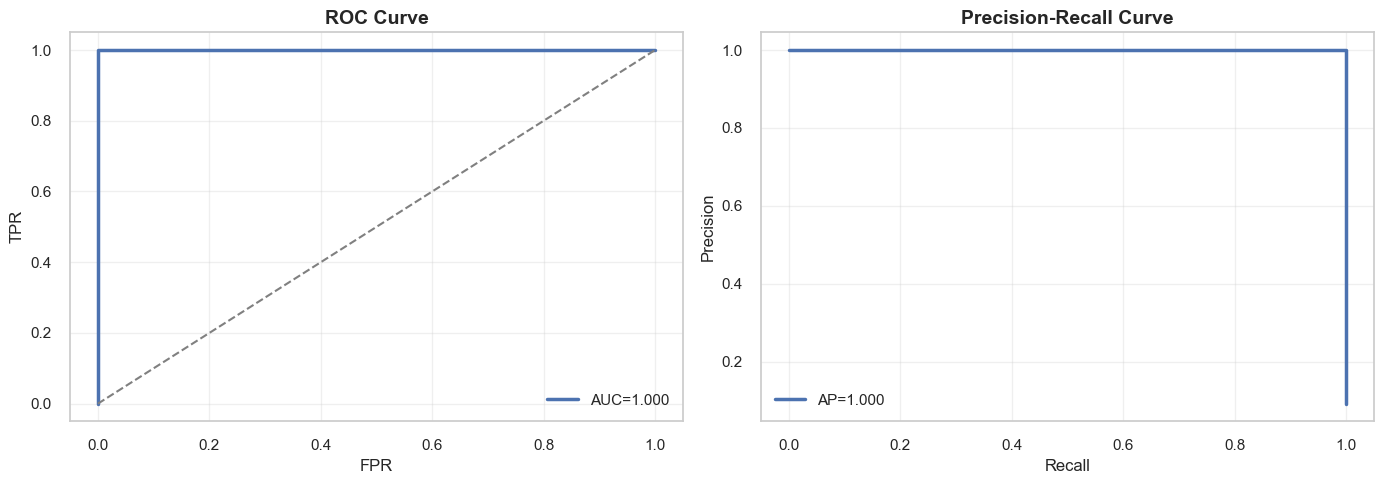

✓ Evaluation plots shown


In [14]:
# ROC & PR curves
fpr, tpr, _ = roc_curve(test_y, test_proba)
prec, recall_vals, _ = precision_recall_curve(test_y, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, linewidth=2.5, label=f'AUC={metrics["roc_auc"]:.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(recall_vals, prec, linewidth=2.5, label=f'AP={metrics["average_precision"]:.3f}')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('✓ Evaluation plots shown')

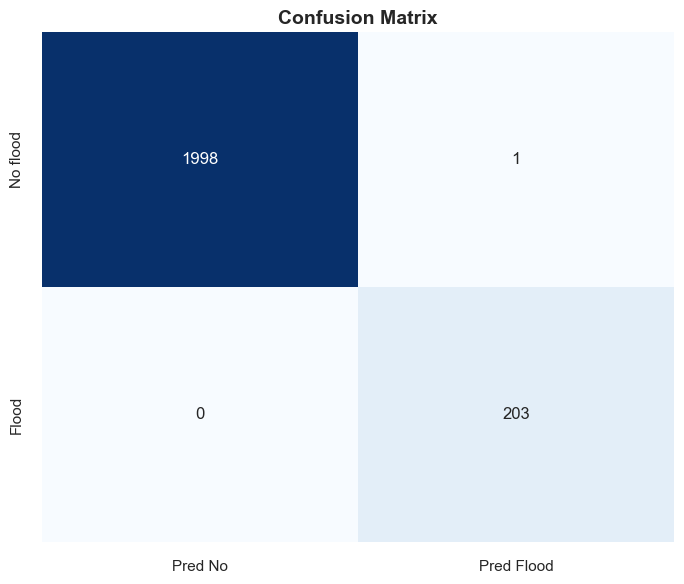


Confusion Matrix:
          Pred No  Pred Flood
No flood     1998           1
Flood           0         203


In [15]:
# Confusion matrix
cm = confusion_matrix(test_y, test_pred)
cm_df = pd.DataFrame(cm, index=['No flood', 'Flood'], columns=['Pred No', 'Pred Flood'])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

print(f'\nConfusion Matrix:')
print(cm_df)

## Section 10: Summary

In [16]:
print('\n' + '='*70)
print('FINAL SUMMARY')
print('='*70)
print(f'\nData:')
print(f'  Train: {len(train)} rows, {train["location"].nunique()} locations')
print(f'  Test:  {len(test)} rows')
print(f'\nModel:')
print(f'  Features: {len(SELECTED_FEATURES)}')
print(f'  Random Forest: 400 trees, depth=10')
print(f'\nPerformance (Test Set):')
for k, v in metrics.items():
    print(f'  {k:20s}: {v:.4f}')
print(f'\n✅ Analysis complete!')


FINAL SUMMARY

Data:


KeyError: 'location'